In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

data = {
    'Name': ['Pikachu', 'Charizard', 'Mewtwo', 'Snorlax', 'Gengar', 'Dragonite', 'Eevee', 'Rayquaza', 'Lucario', 'Greninja', 'Arceus', 'Bulbasaur', 'Gyarados', 'Alakazam', 'Lugia', 'Garchomp', 'Jolteon', 'Blastoise', 'Mudkip', 'Kyogre', 'Tyranitar', 'Gardevoir', 'Mimikyu', 'Zacian', 'Scizor', 'Luxray', 'Decidueye', 'Dragapult', 'Tinkaton', 'Fuecoco'],
    'Type': ['Electric', 'Fire', 'Psychic', 'Normal', 'Ghost', 'Dragon', 'Normal', 'Dragon', 'Fighting', 'Water', 'Normal', 'Grass', 'Water', 'Psychic', 'Psychic', 'Dragon', 'Electric', 'Water', 'Water', 'Water', 'Rock', 'Psychic', 'Ghost', 'Fairy', 'Bug', 'Electric', 'Grass', 'Dragon', 'Fairy', 'Fire'],
    'Region': ['Kanto', 'Kanto', 'Kanto', 'Kanto', 'Kanto', 'Kanto', 'Kanto', 'Hoenn', 'Sinnoh', 'Kalos', 'Sinnoh', 'Kanto', 'Kanto', 'Kanto', 'Johto', 'Sinnoh', 'Kanto', 'Kanto', 'Hoenn', 'Hoenn', 'Johto', 'Hoenn', 'Alola', 'Galar', 'Johto', 'Sinnoh', 'Alola', 'Galar', 'Paldea', 'Paldea'],
    'Legend': [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    'HP': [35, 78, 106, 160, 60, 91, 55, 105, 70, 72, 120, 45, 95, 55, 106, 108, 65, 79, 50, 100, 100, 68, 55, 92, 70, 80, 78, 88, 85, 67],
    'Attack': [55, 84, 110, 110, 65, 134, 55, 150, 110, 95, 120, 49, 125, 50, 90, 130, 65, 83, 70, 100, 134, 65, 90, 130, 130, 120, 107, 120, 75, 45],
    'Defense': [40, 78, 90, 65, 60, 95, 50, 90, 70, 67, 120, 49, 79, 45, 130, 95, 60, 100, 50, 90, 110, 65, 80, 115, 100, 79, 75, 75, 85, 59],
    'Speed': [90, 100, 130, 30, 110, 80, 55, 115, 90, 122, 120, 45, 81, 120, 110, 102, 130, 78, 40, 90, 61, 80, 96, 138, 65, 70, 70, 142, 94, 36],
    'Stage': [2, 3, 1, 2, 3, 3, 1, 1, 2, 3, 1, 1, 2, 3, 1, 3, 2, 3, 1, 1, 3, 3, 1, 1, 2, 3, 3, 3, 3, 1],
    'Capture_Rate': ['High', 'Low', 'Critical', 'Low', 'Medium', 'Low', 'High', 'Critical', 'Medium', 'Medium', 'Critical', 'High', 'Low', 'Medium', 'Critical', 'Low', 'Medium', 'Low', 'High', 'Critical', 'Low', 'Medium', 'High', 'Critical', 'Low', 'Medium', 'Medium', 'Low', 'Medium', 'High']
}

dataset = pd.DataFrame(data)

In [138]:
dataset.head()

,Name,Type,Region,Legend,HP,Attack,Defense,Speed,Stage,Capture_Rate
0,Pikachu,Electric,Kanto,0,35,55,40,90,2,High
1,Charizard,Fire,Kanto,0,78,84,78,100,3,Low
2,Mewtwo,Psychic,Kanto,1,106,110,90,130,1,Critical
3,Snorlax,Normal,Kanto,0,160,110,65,30,2,Low
4,Gengar,Ghost,Kanto,0,60,65,60,110,3,Medium


### 📘 Your "Mastery" Homework Assignment

#### **Challenge 1: The Encoding Architect**
1.  **Ordinal Encoding:** The `Stage` column (1, 2, 3) is already numerical, but represent it as a Category. Does your model treat it differently if you use `StandardScaler` on it versus leaving it alone?
2.  **High Cardinality Fix:** The `Region` column has many unique values. 
    * **Task:** Try One-Hot Encoding `Region`. Then, try **Binning** it (keep 'Kanto' and 'Sinnoh', and mark the rest as 'Other'). 
    * **Question:** How many columns does your $X$ matrix have in both scenarios?

#### **Challenge 2: Multi-Class Target Engineering**
1.  **Label Encode $y$:** Encode `Capture_Rate` into [0, 1, 2, 3].
2.  **Stratified Split:** Use `train_test_split(X, y, test_size=0.2, stratify=y)`. 
    * **Why?** This ensures that "Critical" legendaries appear in **both** the training and testing sets so your model doesn't see a class for the first time during the exam.

#### **Challenge 3: The Model Battle (Decision Tree vs. Random Forest)**
1.  Train a `DecisionTreeClassifier`. Check its accuracy.
2.  Train a `RandomForestClassifier` with `n_estimators=100`.
3.  **The Analysis:** Compare the **Feature Importance**. 
    * `print(rf_model.feature_importances_)`
    * Which feature "matters" most for catching a Pokémon? Is it `Speed`, `Legend`, or `HP`?


In [139]:
dataset.head()

,Name,Type,Region,Legend,HP,Attack,Defense,Speed,Stage,Capture_Rate
0,Pikachu,Electric,Kanto,0,35,55,40,90,2,High
1,Charizard,Fire,Kanto,0,78,84,78,100,3,Low
2,Mewtwo,Psychic,Kanto,1,106,110,90,130,1,Critical
3,Snorlax,Normal,Kanto,0,160,110,65,30,2,Low
4,Gengar,Ghost,Kanto,0,60,65,60,110,3,Medium


In [140]:
dataset['Region'].value_counts()



Region
Kanto     12
Hoenn      4
Sinnoh     4
Johto      3
Alola      2
Galar      2
Paldea     2
Kalos      1
Name: count, dtype: int64

In [141]:
top_3_regions = dataset['Region'].value_counts().nlargest(3).index

dataset['Region'] = dataset['Region'].apply(lambda x: x if x in top_3_regions else 'Other')

In [142]:
dataset.head()

,Name,Type,Region,Legend,HP,Attack,Defense,Speed,Stage,Capture_Rate
0,Pikachu,Electric,Kanto,0,35,55,40,90,2,High
1,Charizard,Fire,Kanto,0,78,84,78,100,3,Low
2,Mewtwo,Psychic,Kanto,1,106,110,90,130,1,Critical
3,Snorlax,Normal,Kanto,0,160,110,65,30,2,Low
4,Gengar,Ghost,Kanto,0,60,65,60,110,3,Medium


In [143]:
from sklearn.preprocessing import LabelEncoder
le_y = LabelEncoder()
dataset['Capture_Rate'] = le_y.fit_transform(dataset['Capture_Rate'])

In [144]:
X = dataset.drop(['Name','Type','Capture_Rate'], axis=1)
y= dataset['Capture_Rate']

In [145]:
X = pd.get_dummies(X, columns=['Region'], drop_first=True).astype(int)

In [146]:
X.head()

,Legend,HP,Attack,Defense,Speed,Stage,Region_Kanto,Region_Other,Region_Sinnoh
0,0,35,55,40,90,2,1,0,0
1,0,78,84,78,100,3,1,0,0
2,1,106,110,90,130,1,1,0,0
3,0,160,110,65,30,2,1,0,0
4,0,60,65,60,110,3,1,0,0


In [147]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(random_state=42, max_depth=7, criterion='entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))


Accuracy: 0.8333333333333334


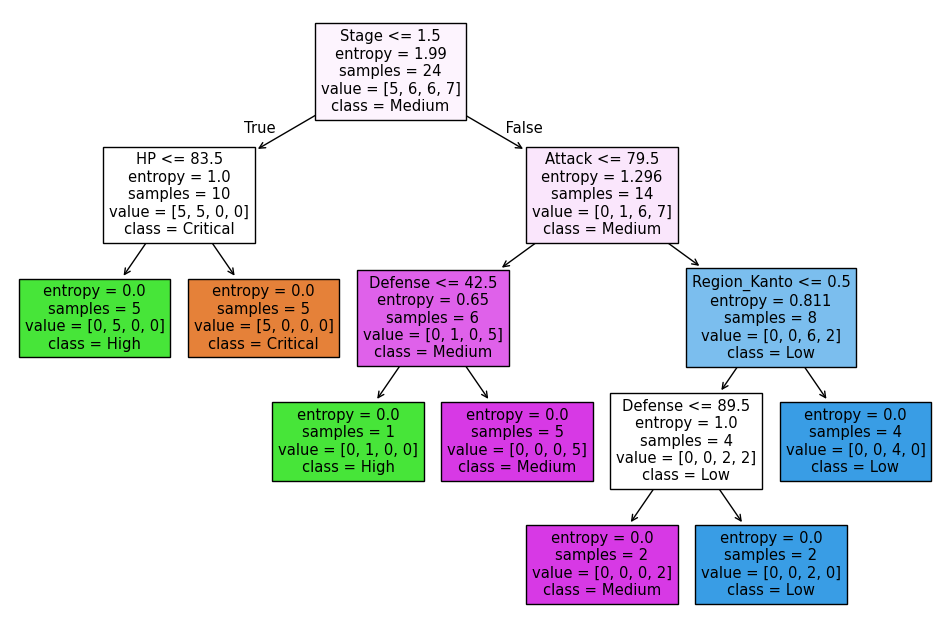

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
from sklearn.tree import plot_tree
plot_tree(model, filled=True, feature_names=X.columns, class_names=le_y.classes_)
plt.show()

In [153]:
import statsmodels.api as sm
X = sm.add_constant(X)  # Adding a constant term for the intercept
model = sm.OLS(y, X).fit()  # Fit the model with all features
p_values = model.pvalues  # Get p-values for each feature
least_significant_feature = p_values.idxmin()  # Identify the least significant feature
print("Least significant feature:", least_significant_feature)

Least significant feature: Stage
